# Prédictions Trading avec Random Forest

In [30]:
#imports pour random forest
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

In [32]:
# --- 1. Chargement et préparation des données ---

# Charger le fichier CSV avec les données préformatées
df = pd.read_csv('Data/cac40_clean_format.csv', parse_dates=['Datetime'])
df.sort_values(by=['Ticker', 'Price', 'Datetime'], inplace=True)
print(df.columns)

# Pivot du DataFrame pour obtenir une colonne par type de prix.
df_wide = df.pivot_table(index=['Datetime', 'Ticker'], columns='Price', values='Value').reset_index()

df_wide = df_wide.sort_values(["Ticker", "Datetime"])
# Calcul du rendement J+1 pour chaque Ticker séparément
df_wide['return'] = df_wide.groupby('Ticker')['Close'].shift(-1) / df_wide['Close'] - 1

# Vérification des colonnes après pivot (on doit avoir une colonne 'Close' issue de la colonne 'Price')
print(df_wide.columns)

Index(['Datetime', 'Price', 'Ticker', 'Value'], dtype='object')
Index(['Datetime', 'Ticker', 'Close', 'High', 'Low', 'Open', 'Volume',
       'return'],
      dtype='object', name='Price')


In [34]:
# --- 2. Définition des labels ---

# Ici, nous allons utiliser la colonne 'Close' pour calculer le rendement.
# On trie par date pour être sûr que les calculs temporels sont corrects.
df_wide = df_wide.sort_values('Datetime')

seuil = 0.01

# Calcul du rendement du jour suivant à partir du prix de clôture
df_wide['return'] = df_wide['Close'].shift(-1) / df_wide['Close'] - 1

# Création d'un label binaire : 1 si le rendement est supérieur ou égal au seuil, sinon 0
df_wide['label'] = (df_wide['return'] >= seuil).astype(int)

# Suppression de la dernière ligne, car le rendement n'est pas défini (shift crée une valeur NaN)
df_wide.dropna(subset=['return'], inplace=True)

# Afficher quelques lignes où le label est 1
print(df_wide[df_wide['label'] == 1].head())

Price                  Datetime    Ticker       Close        High         Low  \
0     2023-03-14 08:00:00+00:00     AC.PA   29.330000   29.330000   28.990000   
32    2023-03-14 08:00:00+00:00  STLAP.PA   16.136000   16.186001   15.984000   
22    2023-03-14 08:00:00+00:00     MT.AS   26.950001   26.980000   26.594999   
17    2023-03-14 08:00:00+00:00     HO.PA  129.449997  130.000000  127.599998   
25    2023-03-14 08:00:00+00:00    PUB.PA   72.620003   72.699997   72.019997   

Price        Open  Volume    return  label  
0       29.049999     0.0  1.128196      1  
32      16.122000     0.0  8.279872      1  
22      26.844999     0.0  3.803339      1  
17     127.650002     0.0  0.718038      1  
25      72.059998     0.0  0.460479      1  


In [35]:
# --- 3. Définition des features ---

# On utilise les colonnes de prix et volume, et éventuellement des indicateurs techniques si disponibles
features = ['Open', 'High', 'Low', 'Close', 'Volume']
if 'RSI' in df_wide.columns:
    features.append('RSI')
if 'MACD' in df_wide.columns:
    features.append('MACD')

In [36]:
X = df_wide[features]
y = df_wide['label']

# --- 4. Séparation train/test ---

print("Nombre total d'échantillons :", len(df_wide))

# Calcul de la taille du training set à 70%
train_size = int(0.7 * len(df_wide))
print("Taille train :", train_size, "Taille test :", len(df_wide) - train_size)

# Séparation en gardant l'ordre chronologique
X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

Nombre total d'échantillons : 187345
Taille train : 131141 Taille test : 56204


In [37]:
# --- 5. Entraînement du modèle RandomForest ---

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prédiction sur l'ensemble de test
y_pred = rf.predict(X_test)

# Évaluation du modèle
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.737456408796527
              precision    recall  f1-score   support

           0       0.73      0.75      0.74     28204
           1       0.74      0.73      0.73     28000

    accuracy                           0.74     56204
   macro avg       0.74      0.74      0.74     56204
weighted avg       0.74      0.74      0.74     56204



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)
/var/folders/fs/_dcnz0fs75gf03k7nt86ptj40000gn/T/ipykernel_27047/3682556480.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test['cumulative_return'].replace([np.inf, -np.inf], np.nan, inplace=True)


ValueError: x and y must have same first dimension, but have shapes (56204,) and (6084,)

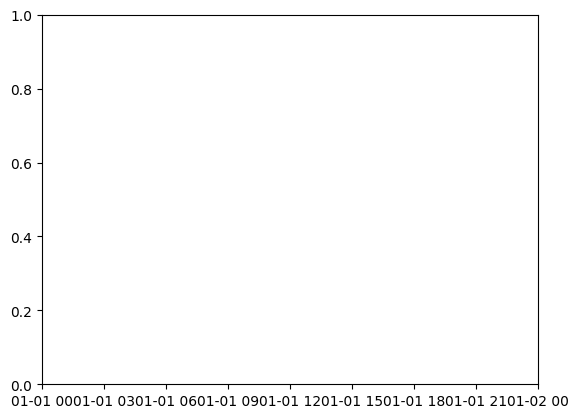

In [45]:
# --- 6. Backtesting de la stratégie ---

# On part du principe que X_test a été défini à partir de df_wide
# Récupérer les dates correspondant à X_test (en utilisant les index)
test_dates = df_wide.loc[X_test.index, 'Datetime']

# Nous simulons une stratégie : si le modèle prédit 1, on "achète" et on récupère le rendement du jour suivant.
# On récupère la colonne 'return' pour la période de test.
X_test = X_test.copy()
X_test['pred'] = y_pred

# Les rendements réels sur le test
X_test['return'] = df_wide.loc[X_test.index, 'return']

# Rendement de la stratégie : si le signal est 1, appliquer le rendement du jour suivant, sinon 0
X_test['strategy_return'] = X_test['pred'] * X_test['return']
X_test['strategy_return'] = X_test['strategy_return'].clip(-0.9, 0.9)

# Calcul du rendement cumulé de la stratégie
X_test['cumulative_return'] = (1 + X_test['strategy_return']).cumprod()

# Remplacer les infinis (s'ils apparaissent) et supprimer les lignes problématiques
X_test['cumulative_return'].replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.dropna(subset=['cumulative_return'], inplace=True)

plt.plot(test_dates.values, X_test['cumulative_return'])
plt.title("Rendement Cumulé de la Stratégie (RandomForest)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

/var/folders/fs/_dcnz0fs75gf03k7nt86ptj40000gn/T/ipykernel_27047/3669944652.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_daily['cumulative_return'].replace([np.inf, -np.inf], np.nan, inplace=True)


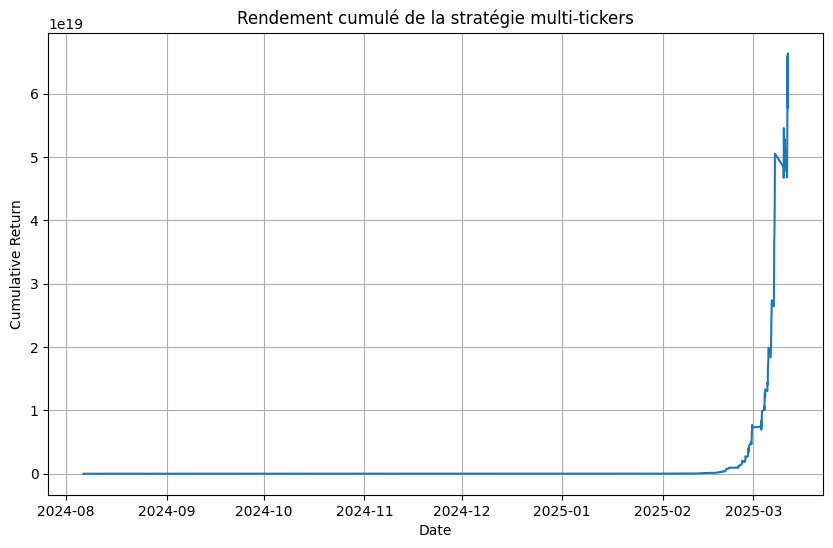

In [43]:
#Stratégie Multi-tickers:

# --- Suppositions préalables ---
# df_wide est votre DataFrame pivoté contenant toutes les données
# La période de test (df_test) est obtenue après le split (par exemple, 30% des données récentes)
# df_wide doit contenir une colonne 'Datetime' (ou 'Date') au format datetime,
# ainsi que la colonne 'return' déjà calculée (en tenant compte du groupby par ticker si nécessaire).

# Supposons que df_test a été défini ainsi :
# train_size = int(0.7 * len(df_wide))
# df_test = df_wide.iloc[train_size:].copy()

# --- Vérification et conversion de la colonne de dates ---
df_test['Datetime'] = pd.to_datetime(df_test['Datetime'], errors='coerce')
df_test.dropna(subset=['Datetime'], inplace=True)
df_test = df_test.sort_values('Datetime')

# --- Ajout des prédictions du modèle ---
# y_pred doit être un tableau (ou une Series) issu de votre modèle RandomForest,
# aligné sur les index de df_test.
df_test['pred'] = y_pred

# --- Calcul du rendement de la stratégie ---
# Si le modèle prédit 1, on applique le rendement réel (colonne 'return'), sinon 0.
df_test['strategy_return'] = df_test['pred'] * df_test['return']

# (Optionnel) Clipper les rendements pour éviter des valeurs extrêmes susceptibles d'exploser le cumul.
df_test['strategy_return'] = df_test['strategy_return'].clip(-0.9, 0.9)

# --- Agrégation par date pour un backtest multi-tickers ---
# On suppose ici que plusieurs tickers sont présents pour une même date.
# On agrège (par exemple, la moyenne) des rendements de la stratégie pour chaque date.
df_daily = df_test.groupby('Datetime', as_index=False).agg({
    'strategy_return': 'mean'
})
df_daily = df_daily.sort_values('Datetime')

# --- Calcul du rendement cumulé ---
df_daily['cumulative_return'] = (1 + df_daily['strategy_return']).cumprod()

# Remplacer les infinis (s'ils apparaissent) et supprimer les lignes problématiques
df_daily['cumulative_return'].replace([np.inf, -np.inf], np.nan, inplace=True)
df_daily.dropna(subset=['cumulative_return'], inplace=True)

# --- Visualisation ---
plt.figure(figsize=(10,6))
plt.plot(df_daily['Datetime'], df_daily['cumulative_return'])
plt.title("Rendement cumulé de la stratégie multi-tickers")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()